In [1]:
import xarray as xr
import numpy as np

In [8]:
xds_post = xr.open_dataset("outputs/Vars_postprocessed_new.nc")
xds_post

<xarray.Dataset> Size: 6MB
Dimensions:   (case_num: 3000, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 24kB 5464 3822 2892 7105 ... 6009 5161 2709 6185
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float32 1MB ...
    Dir       (case_num, time, point) float32 1MB ...
    TPsmoo    (case_num, time, point) float32 1MB ...
    Windv_x   (case_num, time, point) float32 1MB ...
    Windv_y   (case_num, time, point) float32 1MB ...

In [9]:
Dir = xds_post.Dir


Dir_x = np.cos(np.deg2rad(Dir))
Dir_y = np.sin(np.deg2rad(Dir))

DDir = np.arctan2(Dir_y, Dir_x)

xds_post["Dir_x"] = Dir_x
xds_post["Dir_y"] = Dir_y

xds_post = xds_post.drop_vars(["Dir"])
xds_post.to_netcdf("outputs/Vars_postprocessed_new_OK.nc")

In [10]:
xds_post

<xarray.Dataset> Size: 7MB
Dimensions:   (case_num: 3000, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 24kB 5464 3822 2892 7105 ... 6009 5161 2709 6185
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float32 1MB ...
    TPsmoo    (case_num, time, point) float32 1MB ...
    Windv_x   (case_num, time, point) float32 1MB ...
    Windv_y   (case_num, time, point) float32 1MB ...
    Dir_x     (case_num, time, point) float32 1MB 0.5732 0.5797 ... 0.9714
    Dir_y     (case_num, time, point) float32 1MB 0.8194 0.8148 ... 0.2375

In [ ]:
kfold = xr.open_dataset("outputs/OK_k_fold_metamodel_full_linear_OK.nc")
kfold

<xarray.Dataset> Size: 5kB
Dimensions:  (var: 5, n_cases: 11, fold: 10)
Coordinates:
  * var      (var) <U7 140B 'Dir' 'Hsig' 'TPsmoo' 'Windv_x' 'Windv_y'
  * n_cases  (n_cases) int64 88B 500 750 1000 1250 1500 ... 2250 2500 2750 3000
  * fold     (fold) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    rmse     (var, n_cases, fold) float64 4kB ...

In [6]:
def plot_rmse_kfold(results_kfold, name, color):
    # Fondo amarillo pastel con más transparencia
    n_cases = results_kfold.n_cases.values
    fig, ax = plt.subplots(figsize=(10, 5))
    # Línea media con puntos
    ax.plot(
        n_cases,
        results_kfold.rmse.mean(dim='fold'),
        color=color,
        marker='o',
        markersize=3,
        linewidth=2,
        label=f'Mean RMSE {name}'
    )

    # Banda de desviación estándar
    ax.plot(
        n_cases,
        results_kfold.rmse.mean(dim='fold') - results_kfold.rmse.std(dim='fold'),
        color=color,
        linestyle='--',
        linewidth=1,)

    ax.plot(
        n_cases,
        results_kfold.rmse.mean(dim='fold') + results_kfold.rmse.std(dim='fold'),
        color=color,
        linestyle='--',
        linewidth=1,)

    return fig, ax

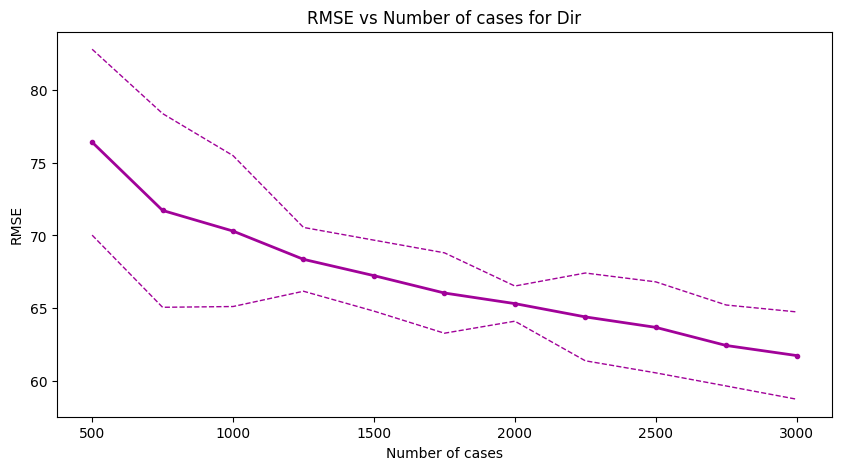

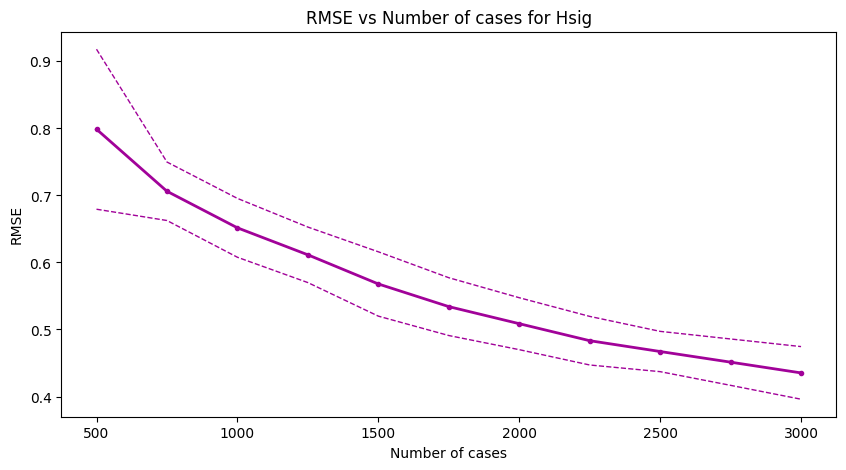

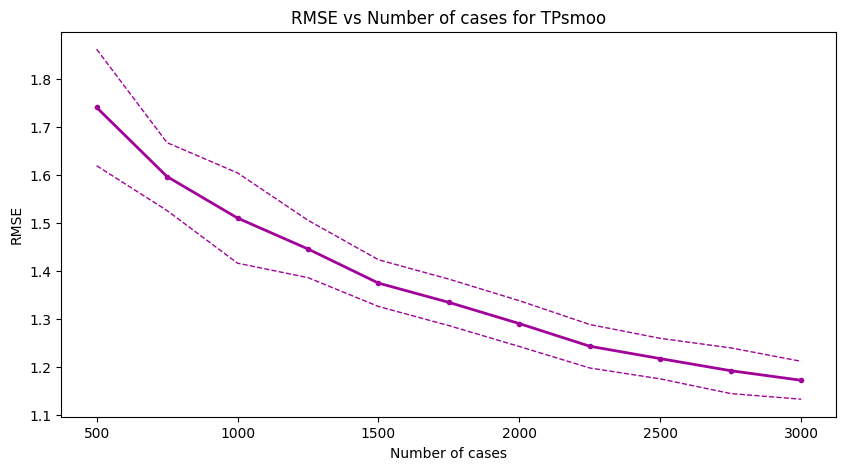

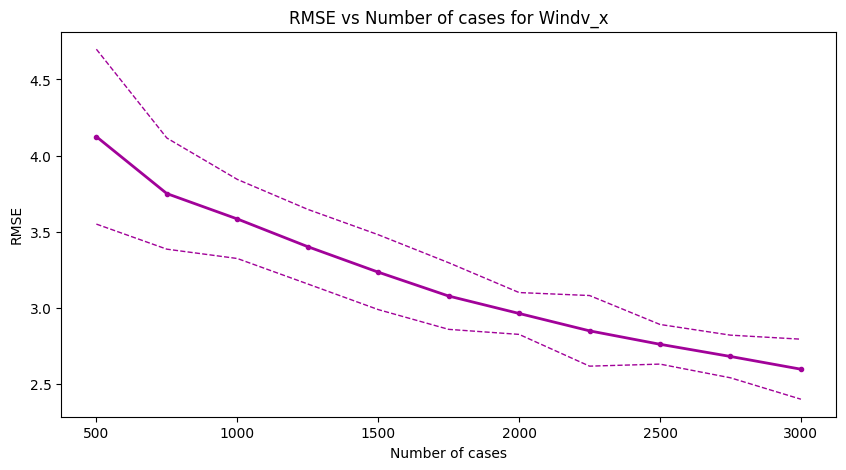

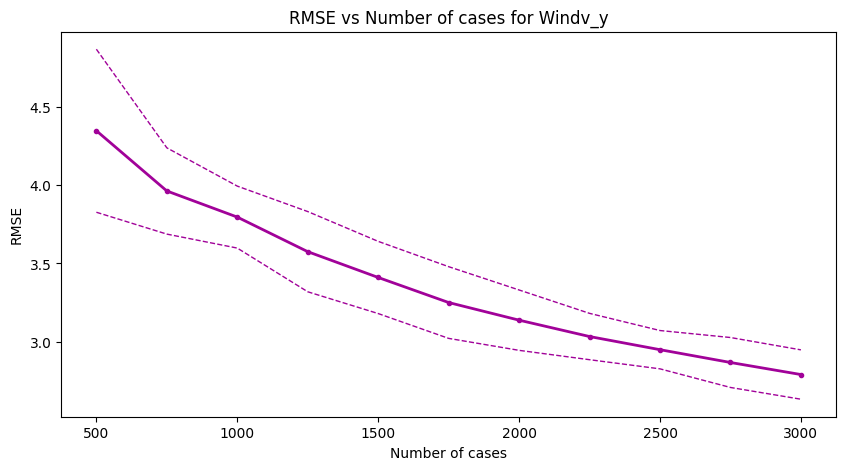

In [7]:
import matplotlib.pyplot as plt

for var in kfold["var"].values:
    results_kfold = kfold.sel(var = var)
    fig, ax = plot_rmse_kfold(results_kfold, "linear", "#a10299" )
    ax.set_xlabel("Number of cases")
    ax.set_ylabel("RMSE")
    ax.set_title(f"RMSE vs Number of cases for {var}")